## Ejercicio Time Series Forecast
Para este ejercicio vamos a predecir cuál será la demanda de pasajeros de una aerolínea, para poder anticiparse a las contrataciones de personal, mantenimiento de las aeronaves y gestión de inventario y comidas.

Para ello, se pide:
1. Carga datos (AirPassengers.csv) y representa la serie. ¿Hay seasonality? ¿Cada cuanto?
2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior. Tienes que usar la función rolling() del DataFrame.
3. Comprueba de manera estadística si la serie es o no stationary.
4. Aplica una transformación logarítmica sobre los datos para mejorar el proceso de transformación de tu time series a stationary. Acuérdate después del forecast de invertir la transformación.
5. Divide en train y test. Guarda 20 muestras para test.
6. Crea tu primer modelo ARIMA. Habrá varias combinaciones en función de sus hiperparámetros... Mide el MAE y RMSE del modelo en predicción. Ten en cuenta el parámetro "m" de la función ARIMA, mediante el cual se establece el seasonality.
7. Representa en una gráfica los datos de test y tus predicciones.
8. Prueba un decission tree y un random forest, a ver qué rendimiento presentan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carga datos y representa la serie

In [14]:
df = pd.read_csv('data/AirPassengers.csv', index_col='date', parse_dates=True)
df.head(144)

,value
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   value      144 non-null    int64  
 1   log_value  144 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 3.4 KB


## 2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window comparando el valor de seasonality obtenido en el apartado anterior

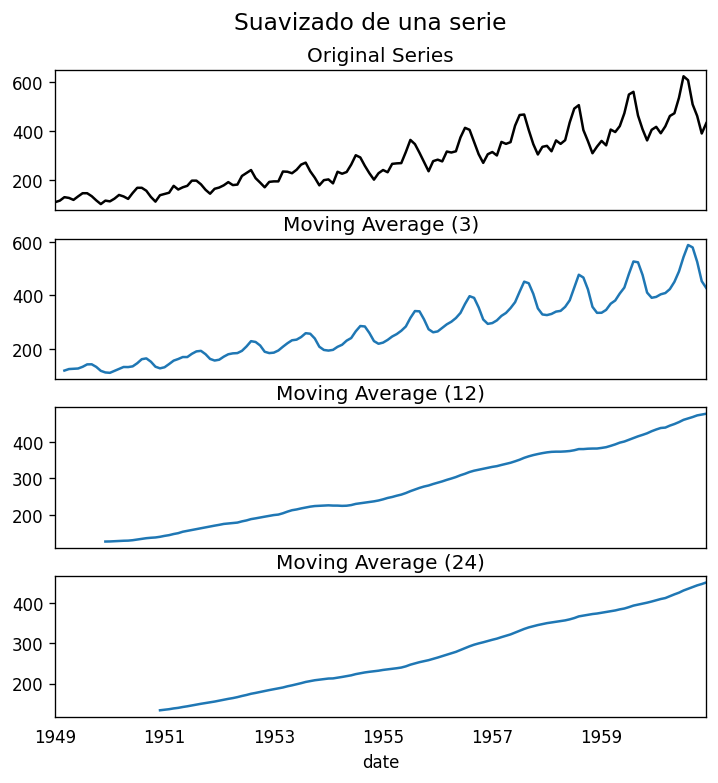

In [5]:
plt.rcParams.update({'xtick.bottom' : False, 'axes.titlepad':5})

# Media móviles
df_ma = df.value.rolling(3).mean()
df_ma_12 = df.value.rolling(12).mean()
df_ma_24 = df.value.rolling(24).mean()

# Plot
fig, axes = plt.subplots(4,1, figsize=(7, 7), sharex=True, dpi=120)
df['value'].plot(ax=axes[0], color='k', title='Original Series')
df_ma.plot(ax=axes[1], title='Moving Average (3)')
df_ma_12.plot(ax=axes[2], title='Moving Average (12)')
df_ma_24.plot(ax=axes[3], title='Moving Average (24)')
fig.suptitle('Suavizado de una serie', y=0.95, fontsize=14)
plt.show()

## 3. Comprueba de manera estadística si la serie es o no estacionaria.

In [7]:
from statsmodels.tsa.stattools import adfuller

serie = df['value']

# --- Prueba 1: Augmented Dickey-Fuller (ADF) ---
# H0: la serie tiene raíz unitaria (no es estacionaria)
# Si p-value > 0.05 → no podemos rechazar H0 → la serie NO es estacionaria
adf_result = adfuller(serie)
print('=== ADF Test ===')
print(f'ADF Statistic : {adf_result[0]:.4f}')
print(f'p-value       : {adf_result[1]:.4f}')
print(f'Valores críticos: {adf_result[4]}')
if adf_result[1] > 0.05:
    print('→ p-value > 0.05: NO rechazamos H0. La serie NO es estacionaria.\n')
else:
    print('→ p-value <= 0.05: Rechazamos H0. La serie ES estacionaria.\n')

=== ADF Test ===
ADF Statistic : 0.8154
p-value       : 0.9919
Valores críticos: {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}
→ p-value > 0.05: NO rechazamos H0. La serie NO es estacionaria.



## 4. Aplica una transformación logarítmica

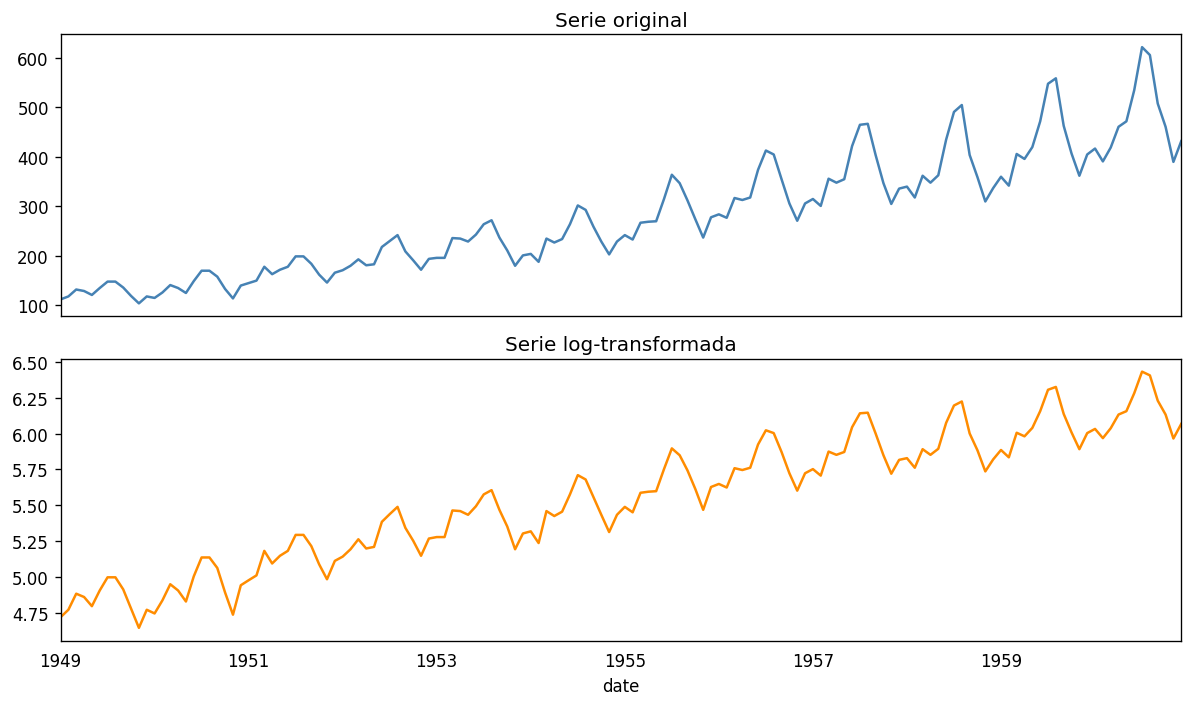

date
1949-01-01    4.718499
1949-02-01    4.770685
1949-03-01    4.882802
1949-04-01    4.859812
1949-05-01    4.795791
Name: log_value, dtype: float64

In [31]:
# Transformación logarítmica
# Guardamos la serie transformada para usarla en el modelado y, más adelante, invertirla con exp().
df['log_value'] = np.log(df['value'])

# Visualización comparativa
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True, dpi=120)
df['value'].plot(ax=ax[0], title='Serie original', color='steelblue')
df['log_value'].plot(ax=ax[1], title='Serie log-transformada', color='darkorange')
fig.tight_layout()
plt.show()

# Comprobamos la nueva serie y la guardamos en una variable para uso posterior.
log_serie = df['log_value']
log_serie.head()

## 5. Divide en train y test. Guarda 20 muestras para test.

In [32]:
# Asegúrate de ejecutar esto en tu celda del Paso 5
t = 20 # 20 muestras para test

# Usamos la serie con transformación logarítmica
train_log = df['log_value'][:-t]
test_log = df['log_value'][-t:]

# Guardamos el test original para poder calcular el error real después
test_orig = df['value'][-t:]

print(f"Train shape: {train_log.shape}, Test shape: {test_log.shape}")

Train shape: (124,), Test shape: (20,)


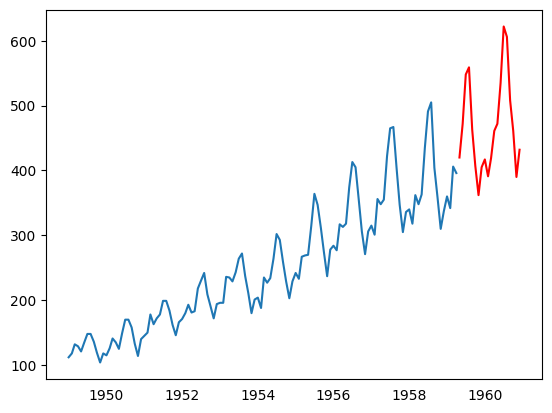

In [33]:
import matplotlib.pyplot as plt

plt.plot(df.index[:-t], train)
plt.plot(df.index[-t:], test, color='r');

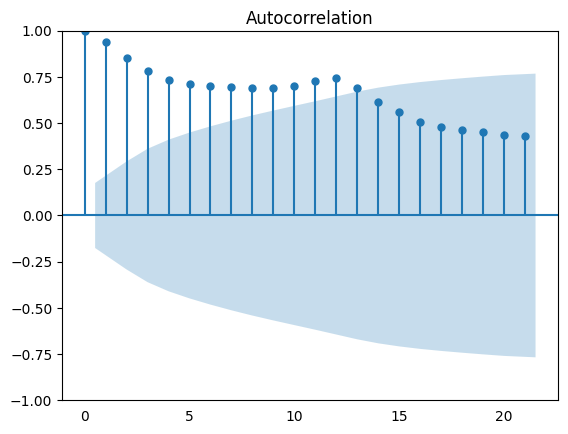

In [34]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(train);

In [35]:
from statsmodels.tsa.ar_model import AutoReg

# AR(1)
mod = AutoReg(train, 1)
res = mod.fit()
print(res.summary())

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  124
Model:                     AutoReg(1)   Log Likelihood                -586.807
Method:               Conditional MLE   S.D. of innovations             28.556
Date:               do., 10 may. 2026   AIC                           1179.615
Time:                        19:37:50   BIC                           1188.051
Sample:                             1   HQIC                          1183.042
                                  124                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.4619      7.195      1.871      0.061      -0.639      27.563
y.L1           0.9552      0.027     35.392      0.000       0.902       1.008
                                    Roots           

## 6. Crea tu primer modelo ARIMA

In [38]:
import itertools
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# Definir un rango más pequeño para que no tarde horas
p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
# Asumimos P, D, Q estacionales simples y m=12
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

In [39]:
results = []
best_aic = float("inf")
best_model = None

print("Buscando el mejor modelo SARIMA...")
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            model = ARIMA(train_log, 
                          order=param, 
                          seasonal_order=param_seasonal)
            model_fit = model.fit()
            
            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_model = model_fit
                
            results.append((param, param_seasonal, model_fit.aic))
        except:
            continue

resultados_df = pd.DataFrame(results, columns=['ARIMA_order', 'Seasonal_order', 'AIC']).sort_values('AIC')
print("Los 5 mejores modelos según AIC:")
display(resultados_df.head())

print(f"\\nMejor modelo encontrado: Order {best_model.model.order}, Seasonal {best_model.model.seasonal_order}")

Buscando el mejor modelo SARIMA...
Los 5 mejores modelos según AIC:


,ARIMA_order,Seasonal_order,AIC
29,"(0, 1, 1)","(1, 0, 1, 12)",-422.652936
53,"(1, 1, 0)","(1, 0, 1, 12)",-422.385186
61,"(1, 1, 1)","(1, 0, 1, 12)",-421.325618
45,"(1, 0, 1)","(1, 0, 1, 12)",-415.950972
21,"(0, 1, 0)","(1, 0, 1, 12)",-415.693692


\nMejor modelo encontrado: Order (0, 1, 1), Seasonal (1, 0, 1, 12)


## 7. Representa en una gráfica los datos de test y tus predicciones.

SARIMA - MAE: 17.41 pasajeros
SARIMA - RMSE: 19.44 pasajeros


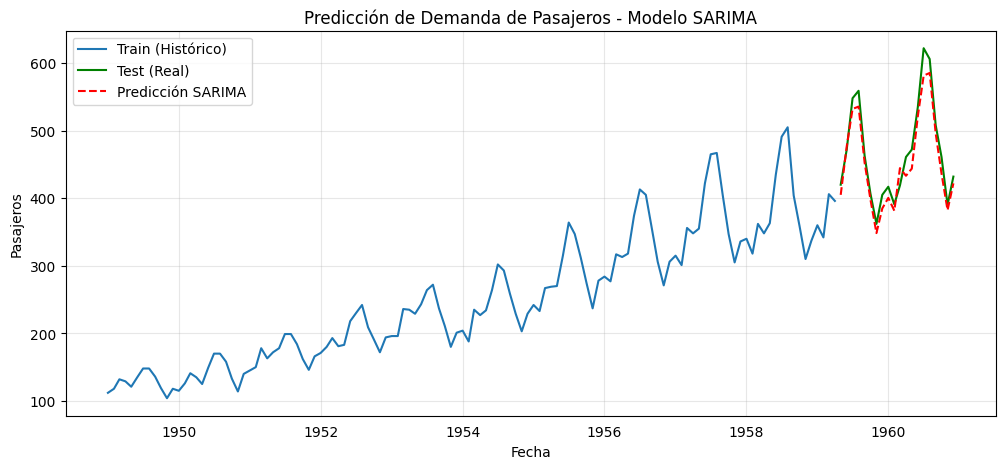

In [40]:
# 1. Hacer la predicción sobre los 20 meses de test
pred_log = best_model.forecast(steps=t)

# 2. Invertir la transformación logarítmica
pred_orig = np.exp(pred_log)

# 3. Calcular métricas
mae_arima = mean_absolute_error(test_orig, pred_orig)
rmse_arima = np.sqrt(mean_squared_error(test_orig, pred_orig))
print(f"SARIMA - MAE: {mae_arima:.2f} pasajeros")
print(f"SARIMA - RMSE: {rmse_arima:.2f} pasajeros")

# 4. Gráfica
plt.figure(figsize=(12, 5), dpi=100)
plt.plot(df.index[:-t], df['value'][:-t], label='Train (Histórico)')
plt.plot(df.index[-t:], test_orig, label='Test (Real)', color='green')
plt.plot(df.index[-t:], pred_orig, label='Predicción SARIMA', color='red', linestyle='--')

plt.title('Predicción de Demanda de Pasajeros - Modelo SARIMA')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Prueba otros modelos supervisados, a ver qué performance presentan.

Decision Tree - MAE: 43.30, RMSE: 53.85
Random Forest - MAE: 38.56, RMSE: 55.80


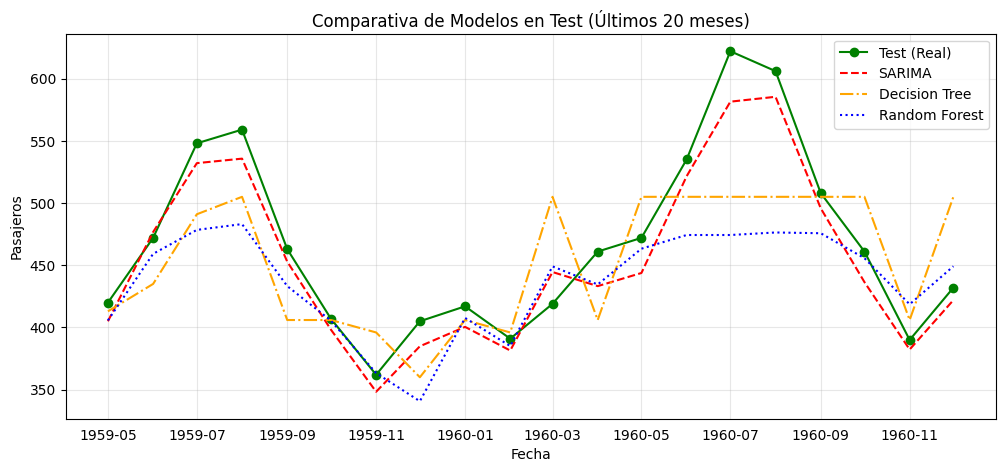

In [41]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# 1. Preparar los datos (Feature Engineering con lags)
# Usaremos 12 lags (1 año de retardo) para capturar la estacionalidad
df_ml = pd.DataFrame({'target': df['log_value']})

for i in range(1, 13):
    df_ml[f'lag_{i}'] = df_ml['target'].shift(i)

# Eliminar los primeros 12 registros que ahora tienen NaNs por los retardos
df_ml.dropna(inplace=True)

# 2. Separar en X (features) e y (target)
X = df_ml.drop('target', axis=1)
y = df_ml['target']

# 3. Train/Test split (últimos 20 para test)
X_train, X_test = X[:-t], X[-t:]
y_train, y_test = y[:-t], y[-t:]

# 4. Entrenar y predecir con Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred_log = dt_model.predict(X_test)
dt_pred = np.exp(dt_pred_log) # Invertir logaritmo

# 5. Entrenar y predecir con Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred_log = rf_model.predict(X_test)
rf_pred = np.exp(rf_pred_log) # Invertir logaritmo

# 6. Calcular Métricas
print(f"Decision Tree - MAE: {mean_absolute_error(test_orig, dt_pred):.2f}, RMSE: {np.sqrt(mean_squared_error(test_orig, dt_pred)):.2f}")
print(f"Random Forest - MAE: {mean_absolute_error(test_orig, rf_pred):.2f}, RMSE: {np.sqrt(mean_squared_error(test_orig, rf_pred)):.2f}")

# 7. Gráfica comparativa
plt.figure(figsize=(12, 5), dpi=100)
plt.plot(df.index[-t:], test_orig, label='Test (Real)', color='green', marker='o')
plt.plot(df.index[-t:], pred_orig, label='SARIMA', color='red', linestyle='--')
plt.plot(df.index[-t:], dt_pred, label='Decision Tree', color='orange', linestyle='-.')
plt.plot(df.index[-t:], rf_pred, label='Random Forest', color='blue', linestyle=':')

plt.title('Comparativa de Modelos en Test (Últimos 20 meses)')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()